### RQ 5: How reliable are small and medium open-source VLLMs for practical use in emotion recognition tasks?

For developers hoping to deploy VLLMs in the real world, the data presents a stark trade-off: getting a "smarter" model means paying a "Latency Penalty." If speed is a priority, the baseline Deepface tool is processes video at a 47.50 FPS (Frames Per Second) with virtually zero delay (0.02s). However, as soon as we switch to small VLLMs (1–5B), that speed collapses by over 96%, dropping to just 1.87 FPS. As we scale up, the Medium tier (6–15B) slows to 1.12 FPS, and the Large tier (16–32B) at 0.70 FPS, taking nearly two seconds to process a single frame. This confirms that while Large VLLMs might be the "smartest" models, they are currently too slow for any task that requires live interaction.

Speed is not the only problem, as we found that reliability is arguably even more critical. We applied a strict "Reliability Filter" to disqualify any model that failed to format its output more than 5% of the time. 14 out of 32 configurations (nearly 44%), mostly from the Medium tier, were unreliable. This proves that a large portion of the open-source landscape is still too fragile for professional use, regardless of how fast or smart the models claim to be.

Based on the results, we face a "Practicality Gap." The only true real-time tool (Deepface) struggles to understand complex emotions (F1 ~0.33), while the smartest models are too slow or unstable. However, there is one standout exception, which is Qwen-2B. Among the reliable models, qwen3-vl:2b-instruct ran at around 3.49 FPS while maintaining a strong F1 score of 0.49. While it is not quite fast enough for live video streaming, it is nearly 5 times faster than the large models and significantly smarter than the baseline, making it the only viable choice for developers who need a balance of speed and intelligence.

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import json
from datasets import load_dataset
from scipy import stats
import os
import math

In [17]:
dataset = load_dataset("Emotion-Aware-AI-Assistant/all_models_results_v1")
df = dataset["train"].to_pandas()

print(f"Full Dataset Shape: {df.shape}")

#We will use 'df_fair' for statistical comparisons (RQ4.1)
#We will use 'df' (full) for failure profiling (RQ4.2)

models_continuous = set(df[df['output_method'] == 'continuous']['model_name'])
models_discrete = set(df[df['output_method'] == 'discrete']['model_name'])

common_models = models_continuous.intersection(models_discrete)
print(f"Models with both methods (Fair Set): {len(common_models)}")

df_fair = df[df['model_name'].isin(common_models)].copy()

print("-" * 30)
print("Columns Available:", df.columns.tolist())
print(df.head())

Full Dataset Shape: (32, 42)
Models with both methods (Fair Set): 8
------------------------------
Columns Available: ['model_name', 'output_method', 'accuracy', 'macro_f1', 'macro_precision', 'macro_recall', 'weighted_f1', 'weighted_precision', 'weighted_recall', 'confusion_matrix_json', 'invalid_counts_json', 'f1_anger', 'f1_disgust', 'f1_fear', 'f1_happiness', 'f1_neutral', 'f1_sadness', 'f1_surprise', 'precision_anger', 'precision_disgust', 'precision_fear', 'precision_happiness', 'precision_neutral', 'precision_sadness', 'precision_surprise', 'recall_anger', 'recall_disgust', 'recall_fear', 'recall_happiness', 'recall_neutral', 'recall_sadness', 'recall_surprise', 'wrong_format', 'emotion_refused', 'emotion_not_listed', 'total_time', 'total_time_hours', 'mean_time', 'response_time_std', 'response_time_mode', 'tie_counts_json', 'method']
        model_name output_method  accuracy  macro_f1  macro_precision  \
0         deepface          None  0.510464  0.327210         0.399528   


In [18]:
def extract_metadata(name):
    name = str(name).lower()
    size_match = re.search(r'(\d+\.?\d*)b', name)
    size = float(size_match.group(1)) if size_match else 0.0

    family = name.split(':')[0].split('-')[0].capitalize()
    return pd.Series([size, family])

df[['size_b', 'family']] = df['model_name'].apply(extract_metadata)

#Small: 1-5B, Medium: 6-15B, Large: 16-32B
bins = [-1, 1, 5, 15, 35]
labels = ['Baseline', 'Small (1-5B)', 'Medium (6-15B)', 'Large (16-32B)']

df['size_tier'] = pd.cut(df['size_b'], bins=bins, labels=labels)

emotions = ['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']
f1_cols = [f'f1_{e}' for e in emotions]

print(df[['model_name', 'size_b','family', 'size_tier']].sort_values(by='size_b').to_string(index=False))
print("\nTier Distribution:")
print(df['size_tier'].value_counts(dropna=False))

                         model_name  size_b    family      size_tier
                           deepface     0.0  Deepface       Baseline
               qwen3-vl:2b-instruct     2.0     Qwen3   Small (1-5B)
               qwen3-vl:2b-instruct     2.0     Qwen3   Small (1-5B)
               qwen3-vl:2b-instruct     2.0     Qwen3   Small (1-5B)
ministral-3:3b-instruct-2512-q4_K_M     3.0 Ministral   Small (1-5B)
                    llava-phi3:3.8b     3.8     Llava   Small (1-5B)
                    llava-phi3:3.8b     3.8     Llava   Small (1-5B)
                    llava-phi3:3.8b     3.8     Llava   Small (1-5B)
               qwen3-vl:4b-instruct     4.0     Qwen3   Small (1-5B)
               qwen3-vl:4b-instruct     4.0     Qwen3   Small (1-5B)
                gemma3:4b-it-q4_K_M     4.0    Gemma3   Small (1-5B)
                gemma3:4b-it-q4_K_M     4.0    Gemma3   Small (1-5B)
               qwen3-vl:4b-instruct     4.0     Qwen3   Small (1-5B)
                gemma3:4b-it-q4_K_

In [19]:
def safe_parse(val):
    if isinstance(val, dict): return val
    if isinstance(val, str):
        try: return json.loads(val)
        except: return {}
    return {}

detected_emotions = set()
target_col = 'confusion_matrix_json' if 'confusion_matrix_json' in df.columns else 'confusion_matrix'
for raw_val in df[target_col]:
    cm = safe_parse(raw_val)
    detected_emotions.update([k for k in cm.keys() if k != 'INVALID'])
final_emotion_list = sorted(list(detected_emotions))

def calculate_metrics(row):
    cm = safe_parse(row.get(target_col, {}))
    ic_col = 'invalid_counts_json' if 'invalid_counts_json' in row.index else 'invalid_counts'
    ic = safe_parse(row.get(ic_col, {}))

    tc = safe_parse(row.get('tie_counts_json', {}))
    tie_count = sum(tc.values()) if isinstance(tc, dict) else 0

    struct_count = 0
    if isinstance(ic, dict):
        for val in ic.values():
            if isinstance(val, dict): struct_count += sum(val.values())
            elif isinstance(val, (int, float)): struct_count += val

    perc_count = 0
    valid_predictions = 0

    if isinstance(cm, dict):
        for actual in final_emotion_list:
            if actual in cm:
                preds = cm[actual]
                row_sum = sum(preds.values())
                if 'INVALID' in preds: row_sum -= preds['INVALID']
                valid_predictions += row_sum

                if actual in preds:
                    perc_count += (row_sum - preds[actual])
                else:
                    perc_count += row_sum

    perc_count += tie_count
    valid_attempts_total = valid_predictions + tie_count

    total_samples = struct_count + valid_attempts_total

    struct_rate = struct_count / total_samples if total_samples > 0 else 0.0
    rel_perc_rate = perc_count / valid_attempts_total if valid_attempts_total > 0 else np.nan
    abs_perc_rate = perc_count / total_samples if total_samples > 0 else 0.0

    return pd.Series([struct_rate, rel_perc_rate, abs_perc_rate])

df[['Struct_Rate', 'Perc_Rate', 'Abs_Perc_Rate']] = df.apply(calculate_metrics, axis=1)


In [20]:
#LATENCY ANALYSIS (Convert Seconds to FPS)
df['FPS'] = 1 / df['mean_time']

print("RQ 5: Practical Reliability (Latency & Stability)")
print("-" * 60)

speed_stats = df.groupby('size_tier', observed=True)[['mean_time', 'FPS']].mean()
print("A. Speed Profile by Tier (Average):")
print(speed_stats.to_string())
print("\n")

#"Reliable" = Structural Error Rate < 5%
reliable_models = df[df['Struct_Rate'] < 0.05].copy()
unreliable_count = len(df) - len(reliable_models)

print(f"B. Reliability Filter (< 5% Crash Rate):")
print(f"   Total Models Tested: {len(df)}")
print(f"   Disqualified (Unstable): {unreliable_count}")
print(f"   Qualified (Reliable):    {len(reliable_models)}")
print("\n")


leaderboard = reliable_models[['model_name', 'size_tier', 'Struct_Rate', 'mean_time', 'FPS', 'macro_f1']]
leaderboard = leaderboard.sort_values('FPS', ascending=False)

print("C. The 'Practicality Leaderboard' (Fastest Reliable Models):")
print(leaderboard[['model_name', 'FPS', 'Struct_Rate', 'macro_f1']].head(7).to_string(index=False))

real_time_candidates = leaderboard[leaderboard['FPS'] > 10]
if not real_time_candidates.empty:
    print(f"\n-> REAL-TIME READY: {len(real_time_candidates)} models can run > 10 FPS while remaining stable.")
    print(f"   Top Pick: {real_time_candidates.iloc[0]['model_name']}")
else:
    print("\n-> NO MODEL is currently ready for high-speed real-time use (> 10 FPS).")

RQ 5: Practical Reliability (Latency & Stability)
------------------------------------------------------------
A. Speed Profile by Tier (Average):
                mean_time        FPS
size_tier                           
Baseline         0.021052  47.500929
Small (1-5B)     0.659912   1.866089
Medium (6-15B)   1.207397   1.119224
Large (16-32B)   1.891677   0.703795


B. Reliability Filter (< 5% Crash Rate):
   Total Models Tested: 32
   Disqualified (Unstable): 14
   Qualified (Reliable):    18


C. The 'Practicality Leaderboard' (Fastest Reliable Models):
          model_name       FPS  Struct_Rate  macro_f1
            deepface 47.500929     0.000000  0.327210
qwen3-vl:2b-instruct  3.489880     0.001630  0.487570
qwen3-vl:2b-instruct  2.430175     0.008866  0.520233
qwen3-vl:4b-instruct  2.412881     0.000000  0.528926
 gemma3:4b-it-q4_K_M  2.156708     0.000261  0.351490
qwen3-vl:4b-instruct  1.583443     0.000456  0.581013
qwen3-vl:8b-instruct  1.569019     0.000261  0.526238

-> 

C:\Users\naste\AppData\Local\Temp\ipykernel_15036\3435610170.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


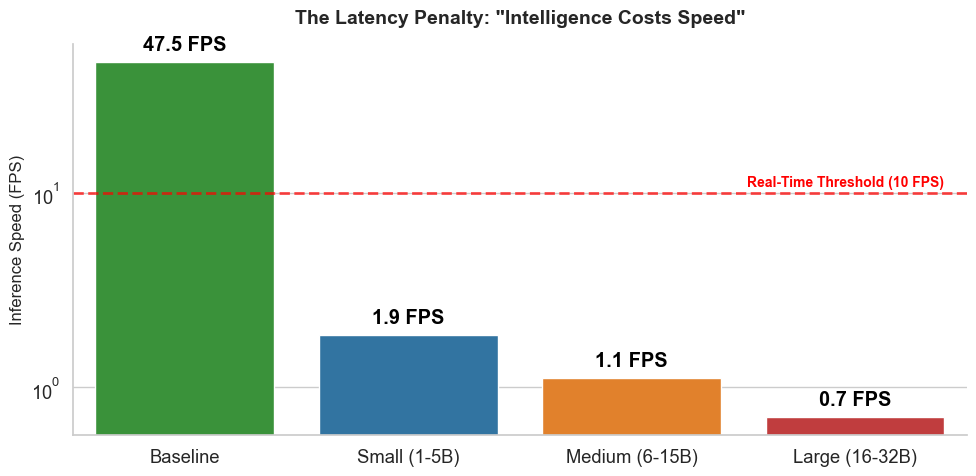

In [22]:
sns.set_theme(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(10, 5))

speed_data = df.groupby('size_tier', observed=True)['FPS'].mean().reset_index()

ax = sns.barplot(
    data=speed_data,
    x='size_tier',
    y='FPS',
    palette=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'],
)

ax.set_title('The Latency Penalty: "Intelligence Costs Speed"', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Inference Speed (FPS)', fontsize=12)
ax.set_xlabel('')
ax.set_yscale('log')

for i, row in speed_data.iterrows():
    ax.text(i, row.FPS * 1.15, f"{row.FPS:.1f} FPS",
            ha='center', fontweight='bold', color='black')

plt.axhline(y=10, color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.text(3.4, 10.5, "Real-Time Threshold (10 FPS)", color='red', fontsize=10, fontweight='bold', va='bottom', ha='right')

sns.despine()
plt.tight_layout()
plt.show()

**Figure 5.a: The Latency Penalty.** A logarithmic comparison of inference speed across size tiers. While the baseline Deepface tool operates at real-time speeds (47.5 FPS), introducing even the smallest VLLMs causes a 96% drop in speed (to 1.87 FPS), rendering them unsuitable for live video processing.

C:\Users\naste\AppData\Local\Temp\ipykernel_15036\2442479992.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


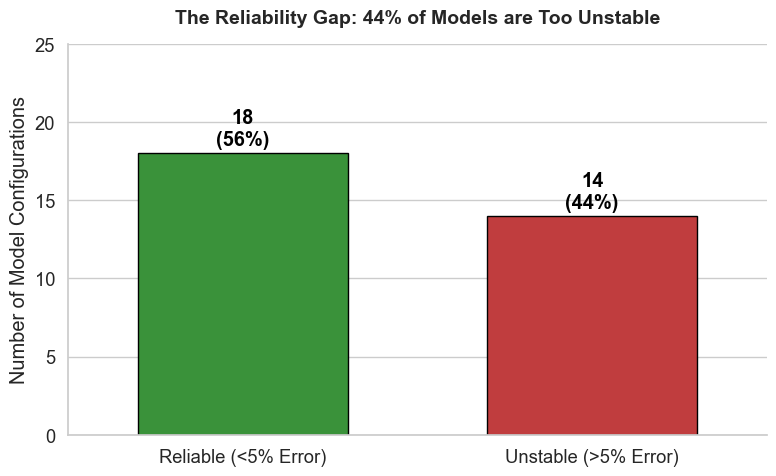

In [23]:
plt.figure(figsize=(8, 5))

df['Reliability_Status'] = np.where(df['Struct_Rate'] < 0.05, 'Reliable (<5% Error)', 'Unstable (>5% Error)')
status_counts = df['Reliability_Status'].value_counts().reset_index()
status_counts.columns = ['Status', 'Count']

colors = {'Reliable (<5% Error)': '#2ca02c', 'Unstable (>5% Error)': '#d62728'}

ax = sns.barplot(
    data=status_counts,
    x='Status',
    y='Count',
    palette=colors,
    edgecolor='black',
    width=0.6
)

ax.set_title('The Reliability Gap: 44% of Models are Too Unstable', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Number of Model Configurations')
ax.set_xlabel('')
ax.set_ylim(0, 25)

for i, row in status_counts.iterrows():
    ax.text(i, row.Count + 0.5, f"{row.Count}\n({row.Count/len(df):.0%})",
            ha='center', fontweight='bold', color='black')

sns.despine()
plt.tight_layout()
plt.show()

**Figure 5.b: The Reliability Filter.** A count of model configurations that pass the "5% Structural Error" threshold. Nearly half of the tested models (14/32) fail to consistently output valid JSON, proving that instability is a major barrier to practical adoption, particularly for the Medium tier.

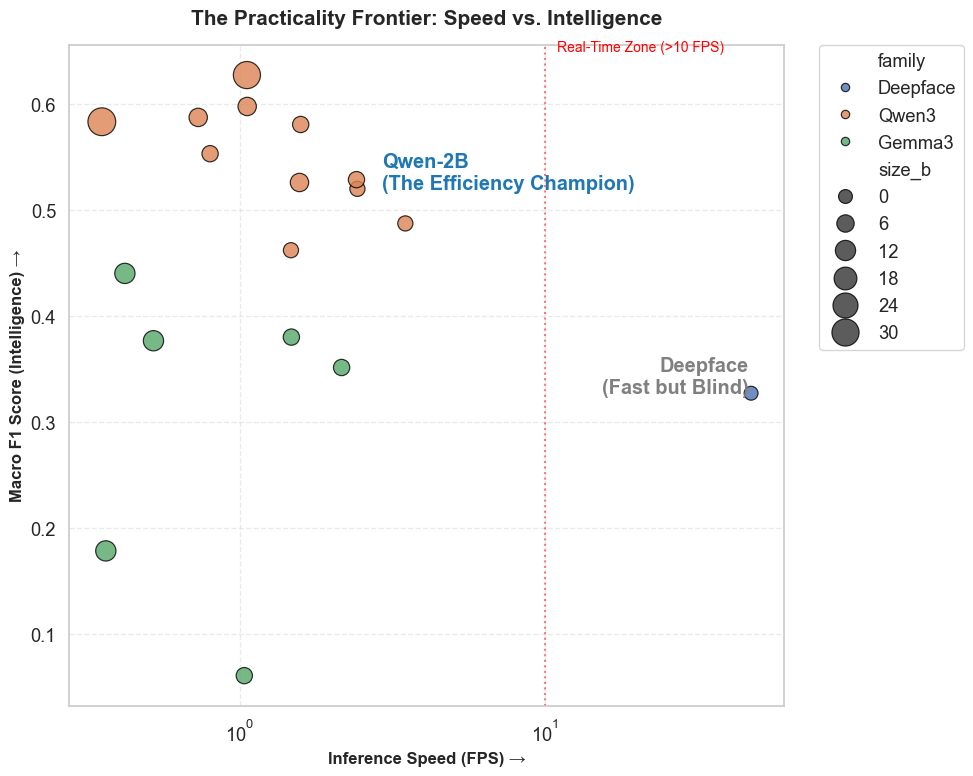

In [25]:
plt.figure(figsize=(10, 8))

plot_df = df[df['Struct_Rate'] < 0.05].copy()

sns.scatterplot(
    data=plot_df,
    x='FPS',
    y='macro_f1',
    hue='family',
    size='size_b',
    sizes=(100, 400),
    palette='deep',
    alpha=0.8,
    edgecolor='black'
)


deepface = plot_df[plot_df['family'] == 'Deepface'].iloc[0]
plt.text(deepface.FPS - 1, deepface.macro_f1, "Deepface\n(Fast but Blind)",
         ha='right', fontweight='bold', color='gray')


qwen_winner = plot_df[(plot_df['family'] == 'Qwen3') & (plot_df['size_b'] == 2.0)].sort_values('macro_f1', ascending=False).iloc[0]
plt.text(qwen_winner.FPS + 0.5, qwen_winner.macro_f1, "Qwen-2B\n(The Efficiency Champion)",
         ha='left', fontweight='bold', color='#1f77b4')

plt.title('The Practicality Frontier: Speed vs. Intelligence', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Inference Speed (FPS) →', fontsize=12, fontweight='bold')
plt.ylabel('Macro F1 Score (Intelligence) →', fontsize=12, fontweight='bold')
plt.xscale('log')
plt.grid(True, linestyle='--', alpha=0.4)


plt.axvline(x=10, color='red', linestyle=':', alpha=0.5)
plt.text(11, 0.65, "Real-Time Zone (>10 FPS)", color='red', fontsize=10, rotation=0)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

**Figure 5.c: The Practicality Frontier.** A scatter plot of Speed (FPS) versus Accuracy (F1). The "Practicality Gap" is visible as no model occupies the top-right corner (Fast & Smart). Deepface is fast but perceptually limited, while Qwen-2B represents the optimal compromise, offering the highest efficiency of any intelligent model.